## Check the Qutip Class: Phase diagram of the Steady states

#### Imports



In [1]:
import numpy as np
import qutip
from qutip import concurrence
from qutip_class import SpinHamiltonian,SteadyStateSolver,SpinOperator,ManyBodyQutipOperator,SpinOperatorOld
import matplotlib.pyplot as plt
from typing import List,Tuple

The Qutip library is focused on numerical tools and methods for Open Quantum System. The aim of this notebook is to show how we can envelope Qutip in a Many-Body fashion.

Furthermore, we develop a Steady State Solver Class. 

#### The building block: A ManyBodyQutipOperator

This class initialize a General ManyBody operator without any restriction about the either the representation or the form. 

The class takes as input a list of qutip.Qobj (local operators) and a description of the ManyBody operator.

In [2]:
xxx=[qutip.sigmax() for i in range(3)]


xxx_mbqo=ManyBodyQutipOperator()

xxx_mbqo.qutip_op=xxx
xxx_mbqo.description="x_0 x_1 x_2 operator"

print(xxx_mbqo)

x_0 x_1 x_2 operator 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]] 



The attributes are:

        -) The quitp operator (qutip.Qobj);
        -) The description (any);

In [3]:

print('Qutip operator=',xxx_mbqo.qutip_op,'\n')


Qutip operator= Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]] 



The methods are:

        -) A printout;
        -) The expectation value in a given state;
        

In [4]:
print(xxx_mbqo)

# define psi
# define the full
# spin up state | 1, 1, 1>
# as a qutip object
psi=qutip.basis(2)
psi_2=qutip.tensor(psi,psi)
psi_3=qutip.tensor(psi_2,psi)

print(xxx_mbqo.expect_value(psi=psi_3))

x_0 x_1 x_2 operator 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]] 

0.0


### Spin Operator: how it works and why

In general a Many-Body operator can be described as a linear combination of local operators tensor products

\begin{equation}
    \hat{O}=\sum_{i j k l} g_{ijkl} \hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l}
\end{equation}

where $A$, $B$, $C$ and $D$ are local operators in a given representation (Fock, Spin, etc...). 

We can then decompose an operator as sum of a density operator

\begin{equation}
    \hat{O}=\sum_{i j k l} g_{ijkl} \hat{O}_{i j k l},
\end{equation}

where 

\begin{equation}
    \hat{O}_{ijkl}=  \hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l}.
\end{equation}

Following this consideration, an Operator can be described as a list of "localized" operators that act in a sum. Each localized operator is described by a tuple of indices, a list of local basis operators and a scalar value 

\begin{equation}
    g_{ijkl}\hat{A_i} \hat{B_j} \hat{C_k} \hat{D_l} \rightarrow [\text{'A'},i,\text{'B'},j,\text{'C'},k,\text{'D'},l]  \; \; g_{ijkl}.
\end{equation}

Therefore, The Spin Operator Class (Fock Operator Class) is characterized by a list of localized observables, with three parameters:

-) Index [ List of Tuples]: The list of strings and indices in which the local operator acts. The strings are:

                                    ['x','y','z','+','-'] (Fock operator ['a','a_dag']).


-) Coupling [ List of floats]: coefficients of the linear combination of the localized operators

#### Example of Spin Operator

Now, we show how to define a simple Ising coupling term as

\begin{equation}
    H=J\sum^{2}_{i=0} X_i X_{i+1} 
\end{equation}

in periodic boundary conditions.

Data

In [8]:
# sites
l=3

# indices
# 1nn coupling term in pbc
idx=[('x',i,) for i in range(l)]

# type of coupling
# along the x direction
# the loop is because the
# number of localized operators
# is 3.

# the coupling is J=1
coupling=[1 for i in range(l)]

# define the abstract operator
# as xx_ao
xx_ao=SpinOperator(index=idx,coupling=coupling,size=l)

xx_ao_old=SpinOperatorOld(index=idx,coupling=coupling,size=l)
# the printout method
# gives a description
# of the operator as
# a dictionary in the
# indeces




print(xx_ao)
 

(couplings, operator) -> 
 ( 1 ,  ('x', 0) ) 
 ( 1 ,  ('x', 1) ) 
 ( 1 ,  ('x', 2) ) 
 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 1. 1. 0. 1. 0. 0. 0.]
 [1. 0. 0. 1. 0. 1. 0. 0.]
 [1. 0. 0. 1. 0. 0. 1. 0.]
 [0. 1. 1. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 1. 1. 0.]
 [0. 1. 0. 0. 1. 0. 0. 1.]
 [0. 0. 1. 0. 1. 0. 0. 1.]
 [0. 0. 0. 1. 0. 1. 1. 0.]] 



#### Attributes of the Abstract Operator

The Abstract operator embedded a general many-body Qutip Object in a more compact form. The methods and attributes are few and simple.  

-) Expt value and Expt value density

Another important methods is the Expectation value. With a given state $\ket{\phi}$, it returns the expectation value:

\begin{equation}
    \braket{\hat{O}}= \sum_{ijkl} g_{ijkl} \braket{A_i B_j C_k D_l}.
\end{equation}

Sometimes, we want to study the expectation value of an operator per site (Correlation functions, magnetizations, etc...). In this case we need to collect the expectation value of each localized operators into a list

\begin{equation}
    T_{ijkl}=g_{ijkl}\braket{O_{ijkl}}
\end{equation}

In [8]:
# define the full
# spin up state | 1, 1, 1>
# as a qutip object
psi=qutip.basis(2)
psi_2=qutip.tensor(psi,psi)
psi_3=qutip.tensor(psi_2,psi)

# AO representation
print(xx_ao)
print('\n')

# expt value of Jxx+hz
xx_z=xx_ao.expect_value(psi=psi_3)
print('expect value=',xx_z,'\n')






(couplings, operator) -> 
 ( 1 ,  ('x', 0, 'y', 0) ) 
 ( 1 ,  ('x', 1, 'y', 1) ) 
 ( 1 ,  ('x', 2, 'y', 2) ) 
 
 Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = False
Qobj data =
[[0.+3.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-3.j]] 



expect value= 3j 



### Ising Hamiltonian

In [1]:
import numpy as np
import qutip
from qutip import concurrence
from qutip_class import SpinHamiltonian,SteadyStateSolver,SpinOperator,ManyBodyQutipOperator,Hamiltonian
import matplotlib.pyplot as plt
from typing import List,Tuple

We want a smart and clear way to define Spin chain Hamiltonians without defining couplings and interactions every time. For this reason we create a subclass of the AbstractOperator called IsingHamiltonian (Actually, even if the attributes and methods are the same of an AbstractOperator, IsingHamiltonian is a set of AbstractOperators, one for each coupling terms and external fields).

The class of Spin Hamiltonians is very large and each Spin Chain can be defined with either simple coupling relations (clean 1nn Ising chain) or very complex (spin glass, long-range interaction Ising chain). The IsingHamiltonian class has different options depending on which kind of Spin Chain you want.

If we want to define a Transverse Ising model with nearest neighbour interaction
\begin{equation}
H=J\sum_i Z_i Z_{i+1} + h \sum_i X_i
\end{equation}

The initialization of the class is simple and intuitive. We need just both the coupling $J$ with the directions ('z','z') and the field $h$ with its direction ('x'), if the boundary conditions are either open or periodic (pbc True or False) and the size of the system

In [7]:
from qutip_class import SpinHamiltonian

size:int=4
j:float=1.
h:float=1.

#s=SpinOperator(index=[('x',i) for i in range(size)],coupling=[1,1,1,1],size=size)

# print(s)

#Hamiltonian(size=size,couplings=[s])





# define the critical transverse ising model 1d
transverse_1nn=SpinHamiltonian(direction_couplings=[('z','z')],field_directions=['x'],coupling_values=[j],field_values=[h],pbc=True,size=size)


print(transverse_1nn)
# # the Qobj instead
# print(transverse_1nn.qutip_op)

Hermitian Check positive! well done! 

Coupling Terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('z', 0, 'z', 1) ) 
 ( 1.0 ,  ('z', 1, 'z', 2) ) 
 ( 1.0 ,  ('z', 2, 'z', 3) ) 
 ( 1.0 ,  ('z', 3, 'z', 0) ) 
 
External fields: 
(couplings, operator) -> 
 ( 1.0 ,  ('x', 0) ) 
 ( 1.0 ,  ('x', 1) ) 
 ( 1.0 ,  ('x', 2) ) 
 ( 1.0 ,  ('x', 3) ) 
 
Other terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('x', 0) ) 
 ( 1.0 ,  ('x', 1) ) 
 ( 1.0 ,  ('x', 2) ) 
 ( 1.0 ,  ('x', 3) ) 
 




Let's see a XY Ising chain with a transverse field
\begin{equation}
H=\sum_i J_1 X_i X_{i+1} + J_2 Y_i Y_{i+1} + h \sum_i Z_i
\end{equation}

In [8]:

# define the critical transverse XY model 1d
xy_1nn=SpinHamiltonian(direction_couplings=[('x','x'),('y','y')],field_directions=['z'],coupling_values=[1.,1.],field_values=[1.],pbc=True,size=size)

# take a look at the Hamiltonian


# the Qobj instead
print(xy_1nn)

Hermitian Check positive! well done! 

Coupling Terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('x', 0, 'x', 1) ) 
 ( 1.0 ,  ('x', 1, 'x', 2) ) 
 ( 1.0 ,  ('x', 2, 'x', 3) ) 
 ( 1.0 ,  ('x', 3, 'x', 0) ) 
 
(couplings, operator) -> 
 ( 1.0 ,  ('y', 0, 'y', 1) ) 
 ( 1.0 ,  ('y', 1, 'y', 2) ) 
 ( 1.0 ,  ('y', 2, 'y', 3) ) 
 ( 1.0 ,  ('y', 3, 'y', 0) ) 
 
External fields: 
(couplings, operator) -> 
 ( 1.0 ,  ('z', 0) ) 
 ( 1.0 ,  ('z', 1) ) 
 ( 1.0 ,  ('z', 2) ) 
 ( 1.0 ,  ('z', 3) ) 
 
Other terms: 
(couplings, operator) -> 
 ( 1.0 ,  ('z', 0) ) 
 ( 1.0 ,  ('z', 1) ) 
 ( 1.0 ,  ('z', 2) ) 
 ( 1.0 ,  ('z', 3) ) 
 




### Find the Steady State

Our aim is to Define a Limbladian with an Hamiltonian and a set of dissipative operators and then find the steady state by exact diagonalization (performed by Qutip). For this reason, we define a simple class called SteadyStateSolver that given a Hamiltonian (AbstractOperator) and a set of dissipative operators (List of Abstract Operator) returns with a method the steady state.

In [9]:
from qutip_class import SteadyStateSolver

# coupling with
# the environment
gamma:float=1.

# operator
dir='-'

# define the dissipative operators
cs:List[SpinOperator]=[]
for i in range(size):
    cs.append(SpinOperator(index=[(dir,i)],coupling=[gamma],size=size))




# let's consider the transverse 
# 1nn Hamiltonian
zz_x_minus=SteadyStateSolver(hamiltonian=transverse_1nn,dissipative_ops=cs)

#compute the steady state
zz_x_minus.get_steady_state(method='svd')



Now, we want to study measures such as the correlations at the centre of the chain or the Negativity in the steady state.

In [10]:
# define the correlation
zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)

# print the result
print(zz.expect_value(zz_x_minus.steady_state))

# Negativity
# Simon's method
def negativity(rho,mask):
    x = qutip.partial_transpose(rho,mask)
    return (x.norm() - 1)/2

# 0 and 1 spins 
mask=[1,1,0,0]
print(zz_x_minus.steady_state)

# compute the 
# negativity of 0 and 1
neg=negativity(zz_x_minus.steady_state,mask)
print(neg)

# we can put the negativity measure
# as a method in the SteadyStateSolver
print(zz_x_minus.negativity(indices=[0,1]))


0.03880748936960671
Quantum object: dims = [[2, 2, 2, 2], [2, 2, 2, 2]], shape = (16, 16), type = oper, isherm = True
Qobj data =
[[ 0.0514754 +0.j          0.00120843-0.01286885j  0.00120843-0.01286885j
  -0.00582582-0.01163194j  0.00120843-0.01286885j  0.00085228-0.00458859j
  -0.00582582-0.01163194j -0.00613966-0.00927687j  0.00120843-0.01286885j
  -0.00582582-0.01163194j  0.00085228-0.00458859j -0.00613966-0.00927687j
  -0.00582582-0.01163194j -0.00613966-0.00927687j -0.00613966-0.00927687j
  -0.01558217-0.01589485j]
 [ 0.00120843+0.01286885j  0.05295096+0.j          0.00240318+0.j
   0.00506054-0.01358598j  0.00302235+0.j         -0.00140361-0.01254126j
   0.00455801-0.00129717j -0.00224759-0.01456354j  0.00240318+0.j
   0.00506054-0.01358598j -0.00179074+0.00021192j  0.00015254-0.00188249j
   0.00455801-0.00129717j -0.00224759-0.01456354j  0.00183652-0.00185855j
  -0.00216594-0.01317242j]
 [ 0.00120843+0.01286885j  0.00240318+0.j          0.05295096+0.j
   0.00506054-0.01358598j 

## Phase Diagram or Scan of a control parameter in a Clean 1nn Transverse Ising Chain

#### Imports

In [12]:
from qutip_class import SpinOperator,SpinHamiltonian,SteadyStateSolver
import numpy as np
import qutip
from tqdm import tqdm
from typing import Dict,List,Tuple

#### Hyperparameters

In [14]:
size:int=4
pbc:bool=False
j:float=1.
h_grid:np.ndarray=np.linspace(0.1,5,100)
coupling_noise:float=1.
dir_coupling:Tuple[str]=('x','x')
dir_field:str='z'
dir_noise:str='-'

method='svd'
# method='iterative-lgmres'
# method='direct'

# define the noise operators
cs:List[SpinOperator]=[]
for i in range(size):
    cs.append(SpinOperator(index=[(dir_noise,i)],coupling=[coupling_noise],size=size))


Define the correlation operators that we want to measure

In [16]:
zz=SpinOperator(index=[('z',int(size/2),'z',int(size/2)+1)],coupling=[1.],size=size)
xx=SpinOperator(index=[('x',int(size/2),'x',int(size/2)+1)],coupling=[1.],size=size)

Loop

In [17]:
neg01=[]
neg02=[]
neg12=[]
xx_vs_h=[]
zz_vs_h=[]
purity=[]

tqdm_iterator=tqdm(h_grid)

for h in tqdm_iterator:
    zz_x=SpinHamiltonian(direction_couplings=[dir_coupling],field_directions=[dir_field],pbc=pbc,size=size,coupling_values=[j],field_values=[h])
    zz_x_minus=SteadyStateSolver(hamiltonian=zz_x,dissipative_ops=cs)
    zz_x_minus.get_steady_state(method=method)
    # compute the negativity
    neg01.append(zz_x_minus.negativity([0,1]))
    neg02.append(zz_x_minus.negativity([0,2]))
    neg12.append(zz_x_minus.negativity([1,2]))
    
    # compute the correlations
    xx_vs_h.append(xx.expect_value(zz_x_minus.steady_state))
    zz_vs_h.append(zz.expect_value(zz_x_minus.steady_state))
    
    #purity
    purity.append(zz_x_minus.purity())

  4%|▍         | 4/100 [00:00<00:04, 19.33it/s]

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 



  7%|▋         | 7/100 [00:00<00:04, 21.07it/s]

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 



 13%|█▎        | 13/100 [00:00<00:03, 22.41it/s]

...

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 



 97%|█████████▋| 97/100 [00:04<00:00, 23.29it/s]

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 

Hermitian Check positive! well done! 



100%|██████████| 100/100 [00:04<00:00, 23.02it/s]

Hermitian Check positive! well done! 



#### Plots

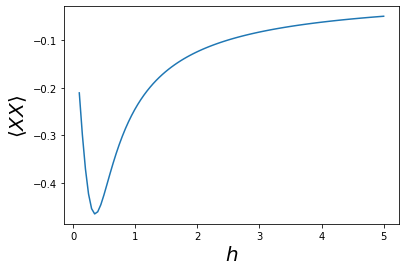

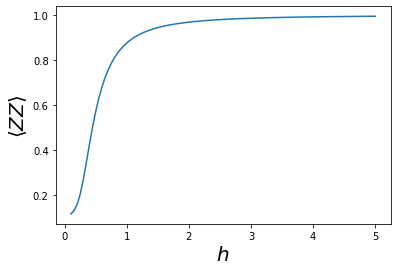

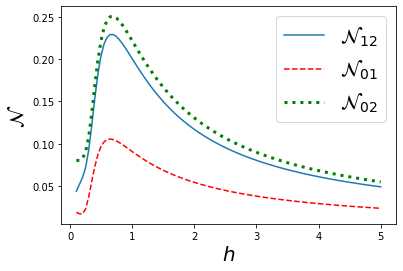

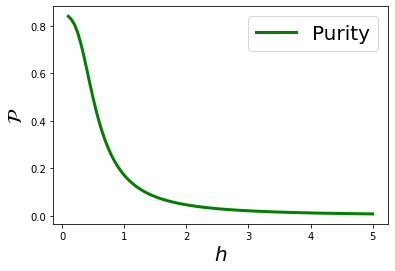

In [18]:
import matplotlib.pyplot as plt

plt.plot(h_grid[0:len(xx_vs_h)],xx_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle XX\rangle$',fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],zz_vs_h)
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\langle ZZ\rangle$',fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],neg12,label=r'$\mathcal{N}_{12}$')
plt.plot(h_grid[0:len(xx_vs_h)],neg01,label=r'$\mathcal{N}_{01}$',linestyle='--',color='red')
plt.plot(h_grid[0:len(xx_vs_h)],neg02,label=r'$\mathcal{N}_{02}$',linestyle=':',linewidth=3,color='green')

plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{N}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()

plt.plot(h_grid[0:len(xx_vs_h)],purity,label=r'Purity',linewidth=3,color='green')
plt.xlabel(r'$h$',fontsize=20)
plt.ylabel(r'$\mathcal{P}$',fontsize=20)
plt.legend(fontsize=20)
plt.show()